In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from tensorflow.keras.datasets import boston_housing

(x_train_set, y_train_set), (x_test, y_test) = boston_housing.load_data()

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
from sklearn.model_selection import train_test_split

x_train, x_valid, y_train, y_valid = train_test_split(x_train_set, y_train_set, random_state=1)

In [4]:
from sklearn.preprocessing import StandardScaler

scal = StandardScaler()
x_train = scal.fit_transform(x_train)
x_valid = scal.transform(x_valid)
x_test = scal.transform(x_test)

In [5]:
x_train_A, x_train_B=x_train[:,:5],x_train[:,3:]
x_valid_A, x_valid_B=x_valid[:,:5],x_valid[:,3:]
x_test_A, x_test_B=x_test[:,:5],x_test[:,3:]

In [6]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Input, concatenate
from tensorflow.keras.optimizers import SGD

In [7]:
keras.backend.clear_session()
np.random.seed(1)
tf.random.set_seed(1)

In [8]:
class MultipleInputsAndOutputsModel(keras.models.Model):
    def __init__(self, units=50, activation='relu', **kwargs):
        super().__init__(**kwargs)
        self.hidden1 = Dense(units, activation=activation)
        self.hidden2 = Dense(units, activation=activation)
        self.main_output = Dense(1)
        self.aux_output = Dense(1)

    def call(self, inputs):
        input_A, input_B = inputs
        hidden1 = self.hidden1(input_B)
        hidden2 = self.hidden2(hidden1)
        concat = concatenate([input_A, hidden2])
        main_output = self.main_output(concat)
        aux_output = self.aux_output(hidden2)
        return main_output, aux_output

model = MultipleInputsAndOutputsModel(30, activation='relu')

In [9]:
model.compile(loss=['mse','mse'],loss_weights=[0.9,0.1],optimizer=SGD(learning_rate=1e-3))

In [10]:
train=model.fit([x_train_A,x_train_B],[y_train,y_train],epochs=20,validation_data=([x_valid_A,x_valid_B],[y_valid,y_valid]))

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - loss: 566.3260 - mse_loss: 548.1962 - val_loss: 516.8267 - val_mse_loss: 562.2120
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 463.3763 - mse_loss: 524.0763 - val_loss: 276.4503 - val_mse_loss: 486.1192
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 198.7411 - mse_loss: 423.3678 - val_loss: 89.9797 - val_mse_loss: 320.5297
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 71.8635 - mse_loss: 280.3661 - val_loss: 54.5699 - val_mse_loss: 219.5894
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 44.4606 - mse_loss: 191.9593 - val_loss: 40.0304 - val_mse_loss: 151.6899
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 32.5034 - mse_loss: 130.6440 - val_loss: 31.8703 - val_mse_loss: 105.4188
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 25.6348 - mse_loss: 88.4890 - val_loss: 26.7701 - val_mse_loss: 74.2833
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 21.3505 

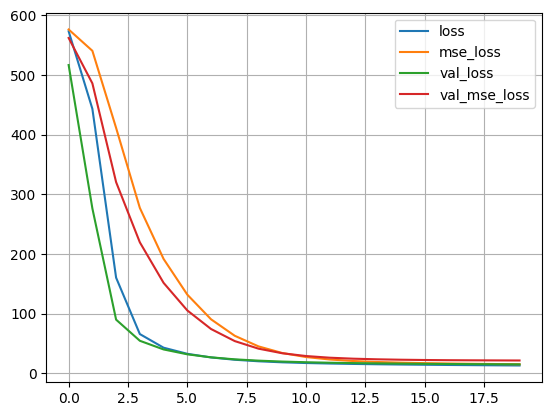

In [12]:
pd.DataFrame(train.history).plot()
plt.grid(True)
plt.show()

In [13]:
model.evaluate([x_test_A,x_test_B],[y_test,y_test])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 20.3314 - mse_loss: 31.5761


[25.871723175048828, 51.246612548828125, 51.246612548828125]

In [14]:
model.predict((x_test_A[:3],x_test_B[:3]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step


(array([[ 8.344875],
        [15.965095],
        [21.054895]], dtype=float32),
 array([[ 7.914729],
        [14.224803],
        [20.560694]], dtype=float32))

In [15]:
y_test[:3]

array([ 7.2, 18.8, 19. ])